In [1]:
# https://www.kaggle.com/code/furkangazidinler/stress-digital-habits-a-predictive-study/notebook
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv('index.csv')

In [3]:
df.head()

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0.0,35.0,119.0,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0.0,16.0,299.0,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0.0,17.0,21.0,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0.0,3.0,220.0,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4.0,92.0,167.0,5.99


In [4]:
df.info()
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 14030 entries, 0 to 14029
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           14030 non-null  int64  
 1   age                               14030 non-null  int64  
 2   gender                            14030 non-null  str    
 3   occupation                        14030 non-null  str    
 4   daily_screen_time_hours           14030 non-null  float64
 5   phone_usage_before_sleep_minutes  14030 non-null  int64  
 6   sleep_duration_hours              14030 non-null  float64
 7   sleep_quality_score               14030 non-null  float64
 8   stress_level                      14029 non-null  float64
 9   caffeine_intake_cups              14029 non-null  float64
 10  physical_activity_minutes         14029 non-null  float64
 11  notifications_received_per_day    14029 non-null  float64
 12  mental_fatigue_

In [5]:
df.isna().sum()

user_id                             0
age                                 0
gender                              0
occupation                          0
daily_screen_time_hours             0
phone_usage_before_sleep_minutes    0
sleep_duration_hours                0
sleep_quality_score                 0
stress_level                        1
caffeine_intake_cups                1
physical_activity_minutes           1
notifications_received_per_day      1
mental_fatigue_score                1
dtype: int64

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,14030.0,7015.500000,4050.256473,1.0,3508.2500,7015.50,10522.75,14030.0
age,14030.0,38.529081,12.006591,18.0,28.0000,39.00,49.00,59.0
daily_screen_time_hours,14030.0,5.502570,2.599255,1.0,3.2600,5.49,7.76,10.0
phone_usage_before_sleep_minutes,14030.0,59.760014,34.638690,0.0,30.0000,60.00,90.00,119.0
sleep_duration_hours,14030.0,6.516319,1.451287,4.0,5.2600,6.50,7.80,9.0
sleep_quality_score,14030.0,6.242949,1.717752,1.0,4.9925,6.24,7.50,10.0
stress_level,14029.0,6.984083,2.747421,1.0,4.7600,7.40,10.00,10.0
caffeine_intake_cups,14029.0,1.995866,1.416575,0.0,1.0000,2.00,3.00,4.0
physical_activity_minutes,14029.0,59.256968,34.530036,0.0,29.0000,59.00,89.00,119.0
notifications_received_per_day,14029.0,161.184047,80.798808,20.0,92.0000,162.00,231.00,299.0


In [7]:
df['occupation'].value_counts()

occupation
Manager              1847
Doctor               1796
Software Engineer    1783
Freelancer           1760
Student              1741
Researcher           1734
Designer             1693
Teacher              1676
Name: count, dtype: int64

In [8]:
styled = (df.describe().T.style
          .background_gradient(cmap='viridis')
          .format("{:.2f}")
          .set_caption("Teste")
          .set_properties(**{
        "border": "1px solid white",
        "padding": "6px",
        "font-size": "12px"
    })
          )

styled

,count,mean,std,min,25%,50%,75%,max
user_id,14030.00,7015.50,4050.26,1.00,3508.25,7015.50,10522.75,14030.00
age,14030.00,38.53,12.01,18.00,28.00,39.00,49.00,59.00
daily_screen_time_hours,14030.00,5.50,2.60,1.00,3.26,5.49,7.76,10.00
phone_usage_before_sleep_minutes,14030.00,59.76,34.64,0.00,30.00,60.00,90.00,119.00
sleep_duration_hours,14030.00,6.52,1.45,4.00,5.26,6.50,7.80,9.00
sleep_quality_score,14030.00,6.24,1.72,1.00,4.99,6.24,7.50,10.00
stress_level,14029.00,6.98,2.75,1.00,4.76,7.40,10.00,10.00
caffeine_intake_cups,14029.00,2.00,1.42,0.00,1.00,2.00,3.00,4.00
physical_activity_minutes,14029.00,59.26,34.53,0.00,29.00,59.00,89.00,119.00
notifications_received_per_day,14029.00,161.18,80.80,20.00,92.00,162.00,231.00,299.00


In [9]:
df.head(10)

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0.0,35.0,119.0,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0.0,16.0,299.0,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0.0,17.0,21.0,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0.0,3.0,220.0,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4.0,92.0,167.0,5.99
5,6,56,Male,Teacher,7.26,10,7.79,6.16,10.00,2.0,50.0,198.0,7.85
6,7,36,Female,Teacher,4.56,83,6.81,6.81,5.38,0.0,19.0,39.0,5.52
7,8,40,Male,Manager,3.36,89,6.50,8.75,3.48,2.0,66.0,127.0,4.50
8,9,28,Male,Student,2.30,109,7.57,8.05,3.46,3.0,103.0,99.0,2.52
9,10,28,Female,Manager,9.75,46,4.73,5.52,10.00,3.0,56.0,121.0,10.00


In [10]:
# 
df['digital_intensity_ratio'] = df['daily_screen_time_hours'] / df['sleep_duration_hours']
df['pre_load_sleep_index'] = (df['phone_usage_before_sleep_minutes'] / 60) / (df['daily_screen_time_hours'] + 0.1)
df['total_mental_burden'] = (df['stress_level'] + df['mental_fatigue_score']) / 2
df['activity_balance_score'] = df['physical_activity_minutes'] / (df['daily_screen_time_hours'] * 60 + 0.1)
df['notification_stress_impact'] = df['stress_level'] / (df['notifications_received_per_day'] + 1)


In [11]:
#Tentativa de obter os 3 trabalhos com maior nivel de estresse

nef = df[['occupation',  'stress_level']] 
nef['stress_level'] = nef['stress_level'].fillna(nef['stress_level'].mean()).round(2)

nef


,occupation,stress_level
0,Designer,3.49
1,Teacher,3.01
2,Designer,5.03
3,Software Engineer,10.00
4,Teacher,6.71
...,...,...
14025,Doctor,9.88
14026,Freelancer,3.53
14027,Student,1.30
14028,Manager,10.00


In [12]:
# Agrupando por ocupação e tirando a média do grupo
asdas = nef.groupby('occupation')['stress_level'].mean().sort_values(ascending=False)
asdas

occupation
Student              7.157214
Manager              7.052133
Software Engineer    7.033926
Doctor               6.962227
Researcher           6.936321
Teacher              6.915579
Freelancer           6.906778
Designer             6.899592
Name: stress_level, dtype: float64

In [13]:
teste = nef['occupation'].value_counts().sort_values(ascending=False)
teste

occupation
Manager              1847
Doctor               1796
Software Engineer    1783
Freelancer           1760
Student              1741
Researcher           1734
Designer             1693
Teacher              1676
Name: count, dtype: int64

In [14]:
ajsdk = nef.groupby('occupation').sample(n=1676, random_state=42)
ajsdk['occupation'].value_counts()

occupation
Designer             1676
Doctor               1676
Freelancer           1676
Manager              1676
Researcher           1676
Software Engineer    1676
Student              1676
Teacher              1676
Name: count, dtype: int64

In [15]:
dkalklak = ajsdk.groupby('occupation')['stress_level'].mean().sort_values(ascending=False)
dkalklak

occupation
Student              7.170310
Manager              7.033258
Software Engineer    7.032297
Researcher           6.961766
Doctor               6.957058
Teacher              6.915579
Freelancer           6.905656
Designer             6.904123
Name: stress_level, dtype: float64

In [16]:
high_stress_ocupation = ['Doctor', 'Sfotware Engineer', 'Manager']

df['is_high_stress_job'] = df['occupation'].apply(lambda x: 1 if x in high_stress_ocupation else 0)

In [17]:
# função lambda => lambda argumentos: expressão
x = lambda number1, number2: number1*number2
print(x(2,5))

10


In [18]:
df_clened: pd.DataFrame = df.drop(columns=['user_id'], inplace=False)

In [19]:
numeric_cols = df_clened.select_dtypes(include='number').columns
object_cols = df_clened.select_dtypes(include='object').columns

print("🔢 NUMERIC COLUMNS")
print("-" * 50)

🔢 NUMERIC COLUMNS
--------------------------------------------------


/tmp/ipykernel_14500/2585327493.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df_clened.select_dtypes(include='object').columns


In [20]:
te = df['occupation'].nunique()

print(te)
print('teste')
print(len(df['occupation'].value_counts()))
print(df['gender'].value_counts())

print(df['gender'].nunique())
print('-' * 100)
for n in numeric_cols:
    print(f'{df[n].nunique()} - {n} diferentes')

print('-------')
print(object_cols)
for n in object_cols:
    # print(f'{df[n].nunique()} {n} diferentes')
    nunique = df[n].nunique()
    if nunique < 15:
        print("unique values:", df[n].unique())
    
    
    # print(n)

8
teste
8
gender
Male      6763
Female    6720
Other      547
Name: count, dtype: int64
3
----------------------------------------------------------------------------------------------------
42 - age diferentes
901 - daily_screen_time_hours diferentes
120 - phone_usage_before_sleep_minutes diferentes
501 - sleep_duration_hours diferentes
829 - sleep_quality_score diferentes
900 - stress_level diferentes
5 - caffeine_intake_cups diferentes
120 - physical_activity_minutes diferentes
280 - notifications_received_per_day diferentes
900 - mental_fatigue_score diferentes
13581 - digital_intensity_ratio diferentes
12181 - pre_load_sleep_index diferentes
2401 - total_mental_burden diferentes
12986 - activity_balance_score diferentes
9977 - notification_stress_impact diferentes
2 - is_high_stress_job diferentes
-------
Index(['gender', 'occupation'], dtype='str')
unique values: <StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str
unique values: <StringArray>
[         'Designer',    

In [21]:

print('\n' + '=' * 60)

In [22]:
cols_for_count = []
cols_for_hist = []


for col in df.columns:
    if(df[col].nunique() <= 15):
        cols_for_count.append(col)
    else:
        cols_for_hist.append(col)
        
print(cols_for_count)

['gender', 'occupation', 'caffeine_intake_cups', 'is_high_stress_job']


/tmp/ipykernel_14500/1029703401.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


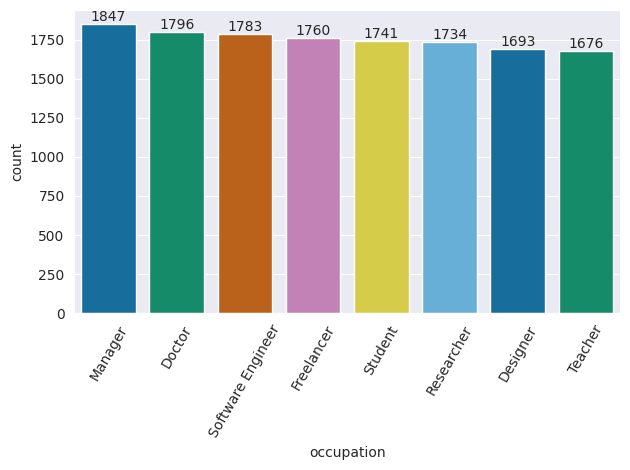

   gender  count  teste
0    Male   6763   6763
1  Female   6720   6720
2   Other    547    547


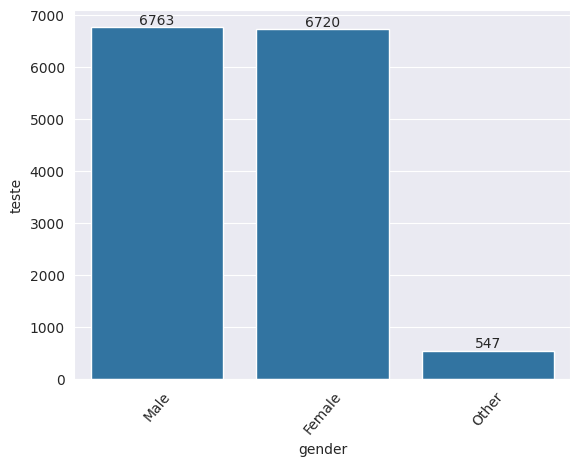

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("darkgrid")

totalByOcupations = df['occupation'].value_counts().reset_index()


ax = sns.barplot(
    data=totalByOcupations, x='occupation', y='count',
    palette=sns.color_palette('colorblind6', len(totalByOcupations))
)


for x in ax.patches:
    height = x.get_height()
    ax.annotate(
        f"{int(height)}",
        xy=(x.get_x() + x.get_width() / 2, x.get_height()),
        ha="center",
        va="bottom",
    )
plt.xticks(rotation=60)  # Inclina e centraliza os rótulos do eixo x
plt.tight_layout()
plt.show()


totalByGender = df['gender'].value_counts().reset_index()
totalByGender['teste'] = totalByGender['count']
print(totalByGender)

ax_2 = sns.barplot(data=totalByGender, x='gender', y='teste')
plt.xticks(rotation=50)

for x in ax_2.patches:
    hight = x.get_height()
    ax_2.annotate(
        f'{int(hight)}',
        xy=(x.get_x() + x.get_width() / 2, x.get_height()),
        ha="center",
        va="bottom",
    )



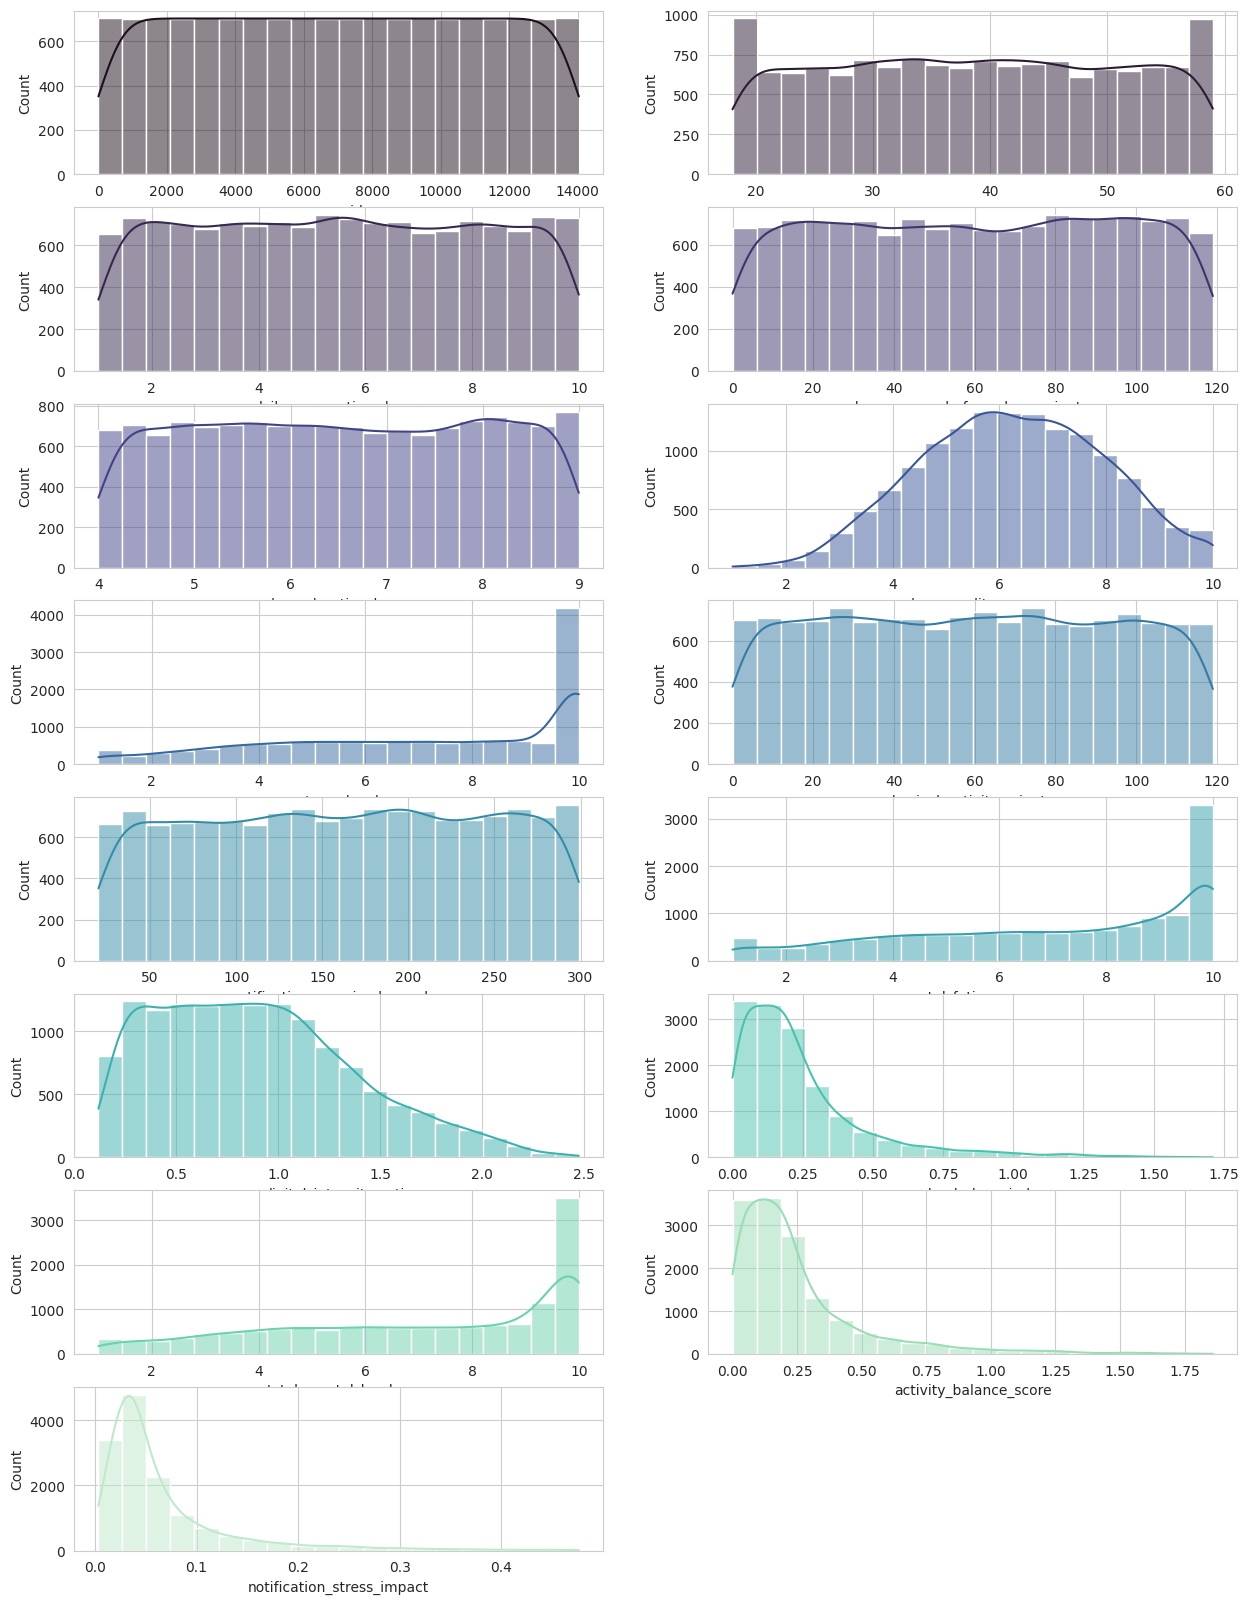

In [24]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(8, 2, figsize=(15, 20))
axes = axes.flatten()


pallet = sns.color_palette('mako', n_colors=len(cols_for_hist))

for i, col in enumerate(cols_for_hist):
    ax = sns.histplot(
        data=df,
        x=col,
        ax=axes[i],
        bins=20,
        kde=True,
        color=pallet[i]
    )
    
if len(cols_for_hist) < len(axes):
    for j in range(len(cols_for_hist), len(axes)):
        fig.delaxes(axes[j])

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5]),
 [Text(0.5, 0, 'user_id'),
  Text(1.5, 0, 'age'),
  Text(2.5, 0, 'daily_screen_time_hours'),
  Text(3.5, 0, 'phone_usage_before_sleep_minutes'),
  Text(4.5, 0, 'sleep_duration_hours'),
  Text(5.5, 0, 'sleep_quality_score'),
  Text(6.5, 0, 'stress_level'),
  Text(7.5, 0, 'caffeine_intake_cups'),
  Text(8.5, 0, 'physical_activity_minutes'),
  Text(9.5, 0, 'notifications_received_per_day'),
  Text(10.5, 0, 'mental_fatigue_score'),
  Text(11.5, 0, 'digital_intensity_ratio'),
  Text(12.5, 0, 'pre_load_sleep_index'),
  Text(13.5, 0, 'total_mental_burden'),
  Text(14.5, 0, 'activity_balance_score'),
  Text(15.5, 0, 'notification_stress_impact'),
  Text(16.5, 0, 'is_high_stress_job')])

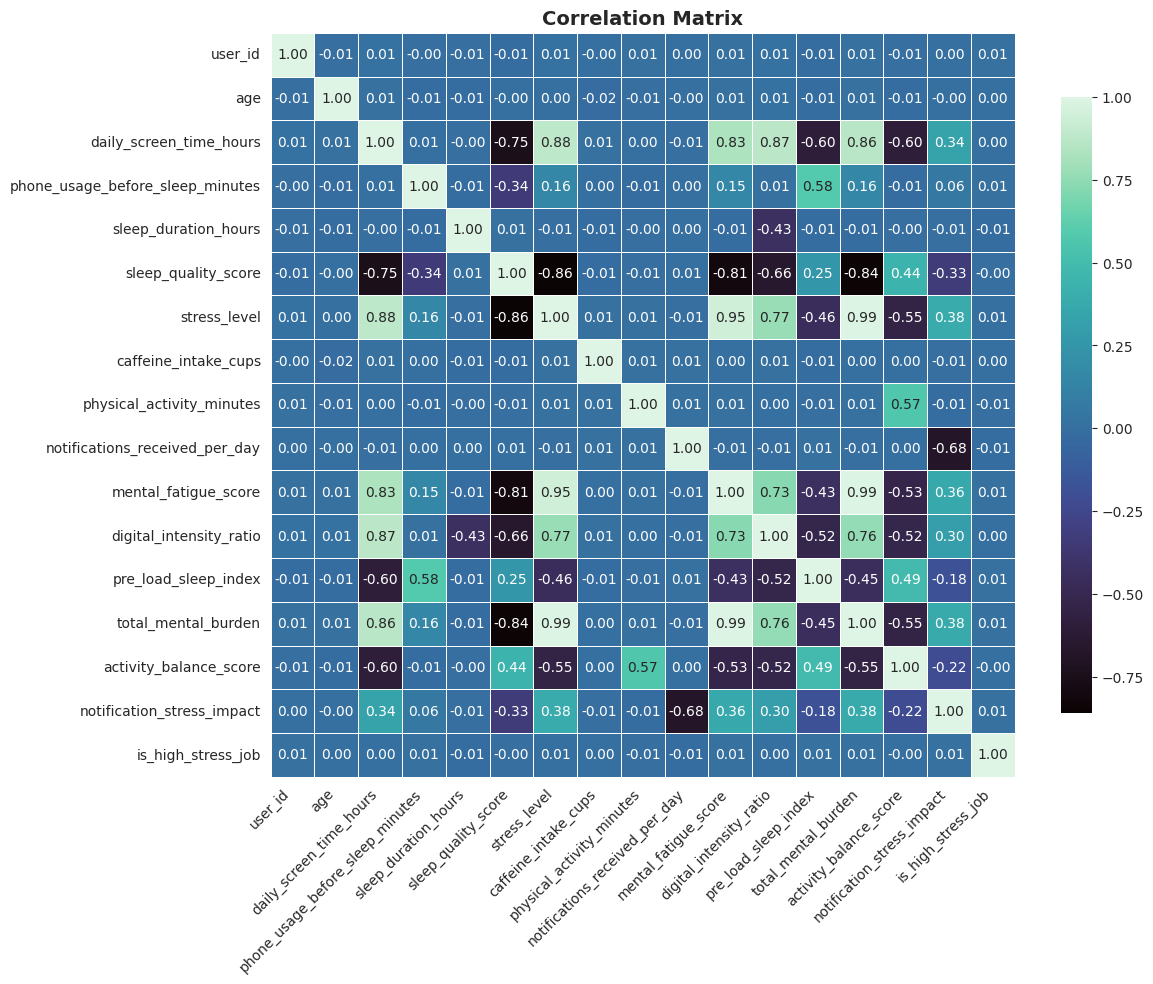

In [25]:
sns.set_style('white')

num_df = df.select_dtypes(include='number')

corr = num_df.corr()

plt.figure(figsize=(12,10))

'''
   annot=True: Exibir valores numéricos dentro de cada célula
   fmt=".2f": O parâmetro fmt em sns.heatmap define o formato dos números exibidos nas células quando annot=True.
   
   fmt=".2f" -> mostra os números com 2 casas decimais (ex: 0.85).
   fmt="d" -> mostra como inteiro.
   fmt=".1f" -> mostra com 1 casa decimal.
   
   cmap: define o mapa de cores
'''

sns.heatmap(
    corr,
    annot=True, 
    fmt=".2f",
    cmap="mako",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix", fontsize=14, weight="bold")
plt.xticks(rotation=45, ha='right')

(array([0.5]), [Text(0.5, 0, 'stress_level')])

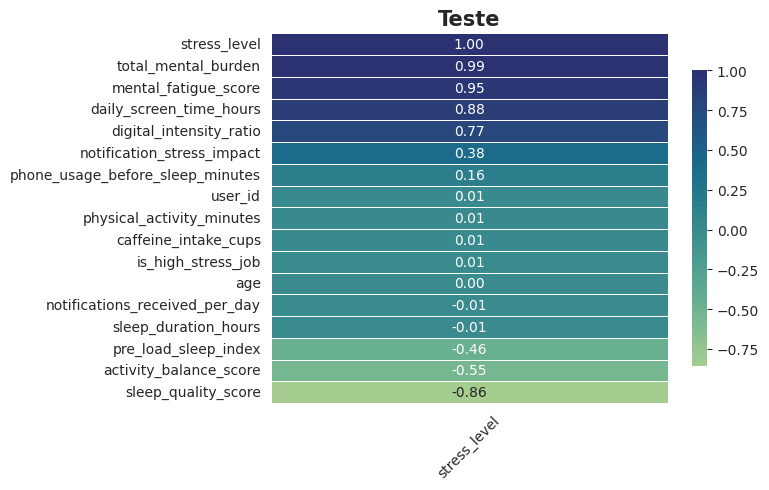

In [26]:
sns.set_style('white')

corr_stress_level = (df.select_dtypes(include='number').corr()[['stress_level']]
                     .sort_values(ascending=False, by='stress_level'))#Seleciona apenas a coluna stress_level


sns.heatmap(
    data=corr_stress_level,
    annot=True,
    linewidths=0.5,
    fmt='.2f',
    cmap='crest',
    cbar_kws={"shrink": 0.8}
)

plt.title('Teste', fontweight='bold', fontsize=15)
plt.xticks(rotation=45)



# corr_stress_level

<h1> Modelando e prevendo </h1>

In [27]:
drop_list = ["stress_level", "mental_fatigue_score", "total_mental_burden", "notification_stress_impact", "user_id"]
df_with_no_null = df.fillna(df.mean(numeric_only=True))
X = df_with_no_null.drop(columns=drop_list)
Y = df_with_no_null['stress_level']

# print(df.isna())
# print(asd.isna())
Y.head()

0     3.49
1     3.01
2     5.03
3    10.00
4     6.71
Name: stress_level, dtype: float64

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

In [29]:
feature_train, feature_test, label_train, label_test = train_test_split(X,Y,test_size=0.2, random_state=42)

# Selecionando apenas features numéricas
numberic_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()
# numberic_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features


/tmp/ipykernel_14500/3612841750.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include='object').columns.tolist()


['gender', 'occupation']

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numberic_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

models = {
    "Linear Regression": LinearRegression(),
    "XGboost Regressor": XGBRegressor(n_estimators=100, learn_rate=0.1, randon_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}
predictions = {}


for name, model in models.items():
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    
    clf.fit(feature_train, label_train)
    y_pred = clf.predict(feature_test)
    predictions[name] = y_pred
    
    results[name] = {
        "R2": r2_score(label_test, y_pred),
        "MAE": mean_absolute_error(label_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(label_test, y_pred))
    }
    

/usr/local/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [14:31:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "learn_rate", "randon_state" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


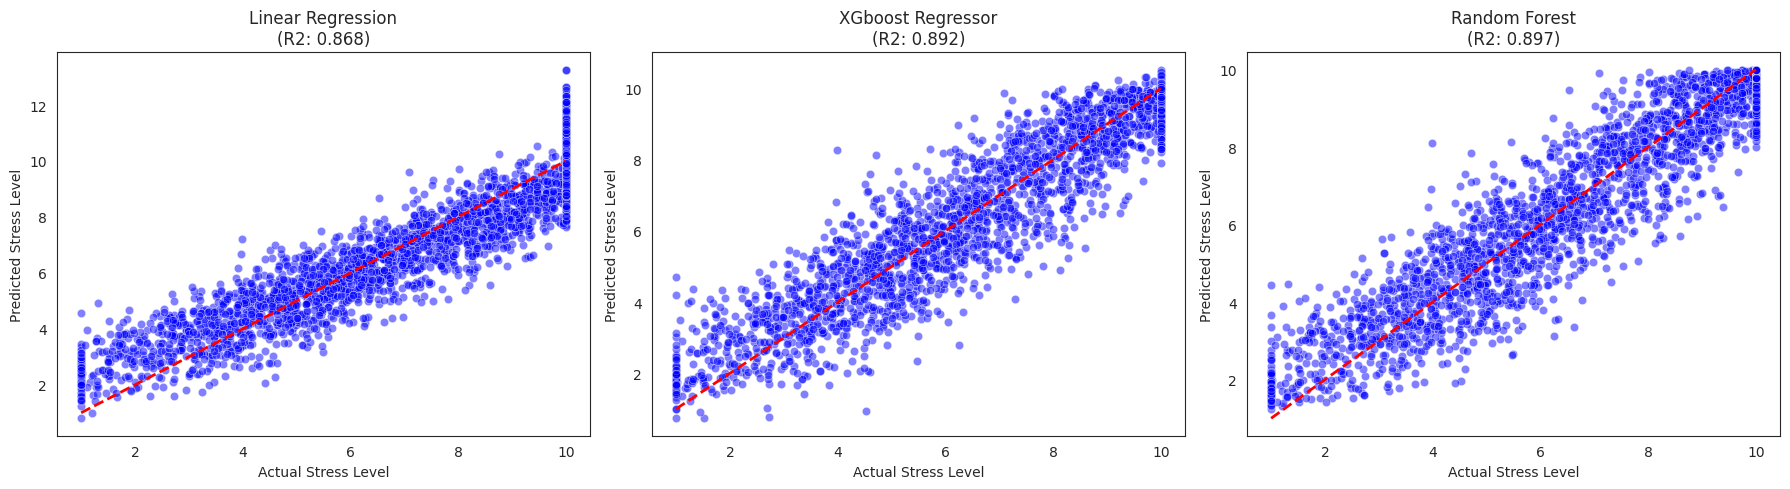

                         R2       MAE      RMSE
Linear Regression  0.867840  0.800304  0.996005
XGboost Regressor  0.892299  0.658940  0.899128
Random Forest      0.897016  0.636941  0.879219


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(predictions.items()):
    sns.scatterplot(x=label_test, y=y_pred, ax=axes[i], alpha=0.5, color='blue')
    axes[i].plot([label_test.min(), label_test.max()], [label_test.min(), label_test.max()], 'r--', lw=2)
    axes[i].set_title(f"{name}\n(R2: {results[name]['R2']:.3f})")
    axes[i].set_xlabel("Actual Stress Level")
    axes[i].set_ylabel("Predicted Stress Level")

plt.tight_layout()
plt.show()

print(pd.DataFrame(results).T)